# Week 6 - Denoising Autoencoder on MNIST

idea is simple - add noise to images and train the model to recover the clean image back
tried 3 different model types to see which works best

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets, transforms

print('torch version:', torch.__version__)
print('gpu available:', torch.cuda.is_available())

torch version: 2.11.0+cpu
gpu available: False


In [ ]:
# just converting to tensor, mnist is already normalized 0-1
transform = transforms.ToTensor()

In [ ]:
train_data = datasets.MNIST('data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('data', train=False, download=True, transform=transform)

print(len(train_data), len(test_data))

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.81MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 155kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.68MB/s]

60000 10000


In [ ]:
valid_size = 0.2
batch_size = 20
num_workers = 0

train_length = len(train_data)
indices = list(range(train_length))
np.random.shuffle(indices)

split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=num_workers)

print(len(train_loader), len(valid_loader), len(test_loader))

2400 600 500


### adding gaussian noise to images
noise_factor controls how much noise - kept it 0.4 after some trial and error

In [ ]:
def add_noise(imgs, noise_factor=0.4):
    noisy = imgs + torch.randn_like(imgs) * noise_factor
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

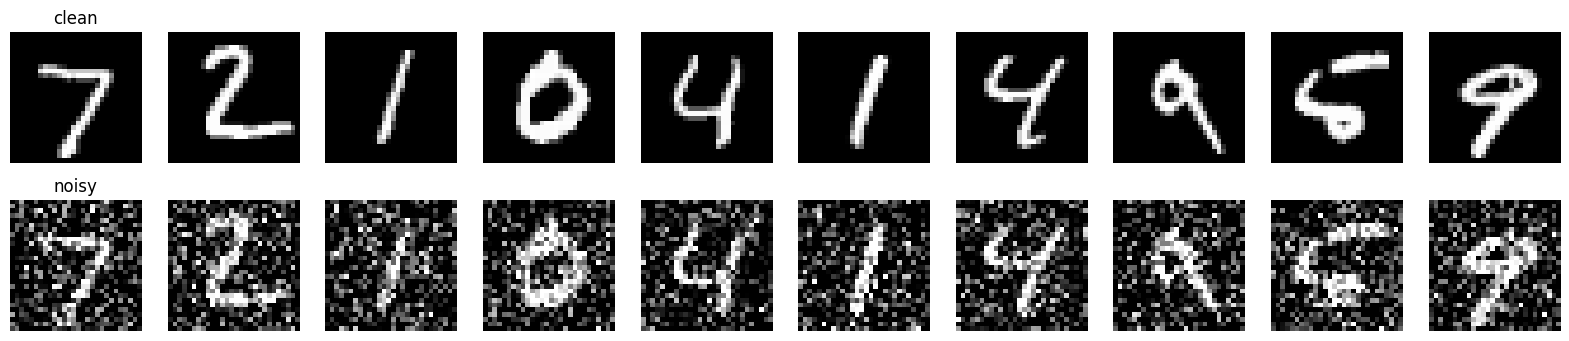

In [ ]:
dataiter = iter(test_loader)
sample_imgs, _ = next(dataiter)
noisy_sample = add_noise(sample_imgs, 0.4)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(np.squeeze(sample_imgs[i].numpy()), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(np.squeeze(noisy_sample[i].numpy()), cmap='gray')
    axes[1, i].axis('off')
axes[0,0].set_title('clean')
axes[1,0].set_title('noisy')
plt.show()

### model definitions

model 1 - basic linear autoencoder (flatten image -> encode -> decode)

model 2 - CNN with transposed convolutions for upsampling in decoder

model 3 - CNN but uses interpolation instead of transposed conv (avoids checkerboard artifacts)

In [ ]:
class F_Auto_MNIST(nn.Module):
    def __init__(self, en_dim=32):
        super(F_Auto_MNIST, self).__init__()
        self.encoder = nn.Linear(784, en_dim)
        self.decoder = nn.Linear(en_dim, 784)

    def forward(self, x):
        x = F.relu(self.encoder(x))
        x = torch.sigmoid(self.decoder(x))
        return x


class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST, self).__init__()

        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.de_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.de_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.relu(self.de_conv1(x))
        x = torch.sigmoid(self.de_conv2(x))
        return x


class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST, self).__init__()

        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.de_conv1 = nn.Conv2d(4, 16, 3, padding=1)
        self.de_conv2 = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.sigmoid(self.de_conv2(x))
        return x

In [ ]:
model_1 = F_Auto_MNIST(en_dim=32)
model_2 = Tran_conv_Auto_MNIST()
model_3 = upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        n = m.in_features
        y = 1.0 / np.sqrt(n)
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda = True
device = torch.device('cuda' if use_cuda and torch.cuda.is_available() else 'cpu')
model_1.to(device)
model_2.to(device)
model_3.to(device)

print(model_1)
print(model_2)
print(model_3)
print('device:', device)

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
)
Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
)
upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
device: cpu


In [ ]:
criteria = nn.MSELoss()

### training function
important thing here - noisy image goes IN, clean image is the TARGET
thats what makes it a denoising autoencoder

In [ ]:
def trainNet(model, lr, state='fully', noise_factor=0.4, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_keeper = {'train': [], 'valid': []}
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss = 0.0
        valid_loss = 0.0

        model.train()
        for images, _ in train_loader:
            images = images.to(device)
            noisy_images = add_noise(images, noise_factor).to(device)

            if state == 'fully':
                images = images.view(images.size(0), -1)
                noisy_images = noisy_images.view(noisy_images.size(0), -1)

            optimizer.zero_grad()
            output = model(noisy_images)
            loss = criteria(output, images)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for images, _ in valid_loader:
                images = images.to(device)
                noisy_images = add_noise(images, noise_factor).to(device)

                if state == 'fully':
                    images = images.view(images.size(0), -1)
                    noisy_images = noisy_images.view(noisy_images.size(0), -1)

                output = model(noisy_images)
                loss = criteria(output, images)
                valid_loss += loss.item()

        train_loss /= len(train_loader)
        valid_loss /= len(valid_loader)
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f'epoch {epoch+1}/{epochs} | train: {train_loss:.6f} | val: {valid_loss:.6f}')

        if valid_loss <= valid_loss_min:
            print(f'  val loss improved {valid_loss_min:.6f} -> {valid_loss:.6f}, saving...')
            torch.save(model.state_dict(), type(model).__name__ + '_denoising.pth')
            valid_loss_min = valid_loss

    return loss_keeper

In [ ]:
m1_loss = trainNet(model_1, lr=0.001, state='fully', noise_factor=0.4)

epoch 1/20 | train: 0.048812 | val: 0.034661
  val loss improved inf -> 0.034661, saving...
epoch 2/20 | train: 0.032414 | val: 0.031213
  val loss improved 0.034661 -> 0.031213, saving...
epoch 3/20 | train: 0.030715 | val: 0.030528
  val loss improved 0.031213 -> 0.030528, saving...
epoch 4/20 | train: 0.030140 | val: 0.030028
  val loss improved 0.030528 -> 0.030028, saving...
epoch 5/20 | train: 0.029866 | val: 0.029843
  val loss improved 0.030028 -> 0.029843, saving...
epoch 6/20 | train: 0.029672 | val: 0.029697
  val loss improved 0.029843 -> 0.029697, saving...
epoch 7/20 | train: 0.029537 | val: 0.029542
  val loss improved 0.029697 -> 0.029542, saving...
epoch 8/20 | train: 0.029410 | val: 0.029414
  val loss improved 0.029542 -> 0.029414, saving...
epoch 9/20 | train: 0.029271 | val: 0.029391
  val loss improved 0.029414 -> 0.029391, saving...
epoch 10/20 | train: 0.029178 | val: 0.029195
  val loss improved 0.029391 -> 0.029195, saving...
epoch 11/20 | train: 0.029082 | va

In [ ]:
m2_loss = trainNet(model_2, lr=0.001, state='conv', noise_factor=0.4)

epoch 1/20 | train: 0.038984 | val: 0.021375
  val loss improved inf -> 0.021375, saving...
epoch 2/20 | train: 0.020177 | val: 0.019269
  val loss improved 0.021375 -> 0.019269, saving...
epoch 3/20 | train: 0.018681 | val: 0.018345
  val loss improved 0.019269 -> 0.018345, saving...
epoch 4/20 | train: 0.017956 | val: 0.017758
  val loss improved 0.018345 -> 0.017758, saving...
epoch 5/20 | train: 0.017608 | val: 0.017467
  val loss improved 0.017758 -> 0.017467, saving...
epoch 6/20 | train: 0.017363 | val: 0.017287
  val loss improved 0.017467 -> 0.017287, saving...
epoch 7/20 | train: 0.017205 | val: 0.017180
  val loss improved 0.017287 -> 0.017180, saving...
epoch 8/20 | train: 0.017035 | val: 0.017177
  val loss improved 0.017180 -> 0.017177, saving...
epoch 9/20 | train: 0.016929 | val: 0.016862
  val loss improved 0.017177 -> 0.016862, saving...
epoch 10/20 | train: 0.016801 | val: 0.016803
  val loss improved 0.016862 -> 0.016803, saving...
epoch 11/20 | train: 0.016757 | va

In [ ]:
m3_loss = trainNet(model_3, lr=0.001, state='conv', noise_factor=0.4)

epoch 1/20 | train: 0.025677 | val: 0.017260
  val loss improved inf -> 0.017260, saving...
epoch 2/20 | train: 0.016385 | val: 0.015745
  val loss improved 0.017260 -> 0.015745, saving...
epoch 3/20 | train: 0.015392 | val: 0.015151
  val loss improved 0.015745 -> 0.015151, saving...
epoch 4/20 | train: 0.014967 | val: 0.014954
  val loss improved 0.015151 -> 0.014954, saving...
epoch 5/20 | train: 0.014696 | val: 0.014585
  val loss improved 0.014954 -> 0.014585, saving...
epoch 6/20 | train: 0.014470 | val: 0.014333
  val loss improved 0.014585 -> 0.014333, saving...
epoch 7/20 | train: 0.014279 | val: 0.014282
  val loss improved 0.014333 -> 0.014282, saving...
epoch 8/20 | train: 0.014174 | val: 0.014111
  val loss improved 0.014282 -> 0.014111, saving...
epoch 9/20 | train: 0.014084 | val: 0.014147
epoch 10/20 | train: 0.013990 | val: 0.014008
  val loss improved 0.014111 -> 0.014008, saving...
epoch 11/20 | train: 0.013938 | val: 0.013909
  val loss improved 0.014008 -> 0.013909

In [14]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_denoising.pth', map_location=device))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_denoising.pth', map_location=device))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_denoising.pth', map_location=device))
print('loaded')

loaded


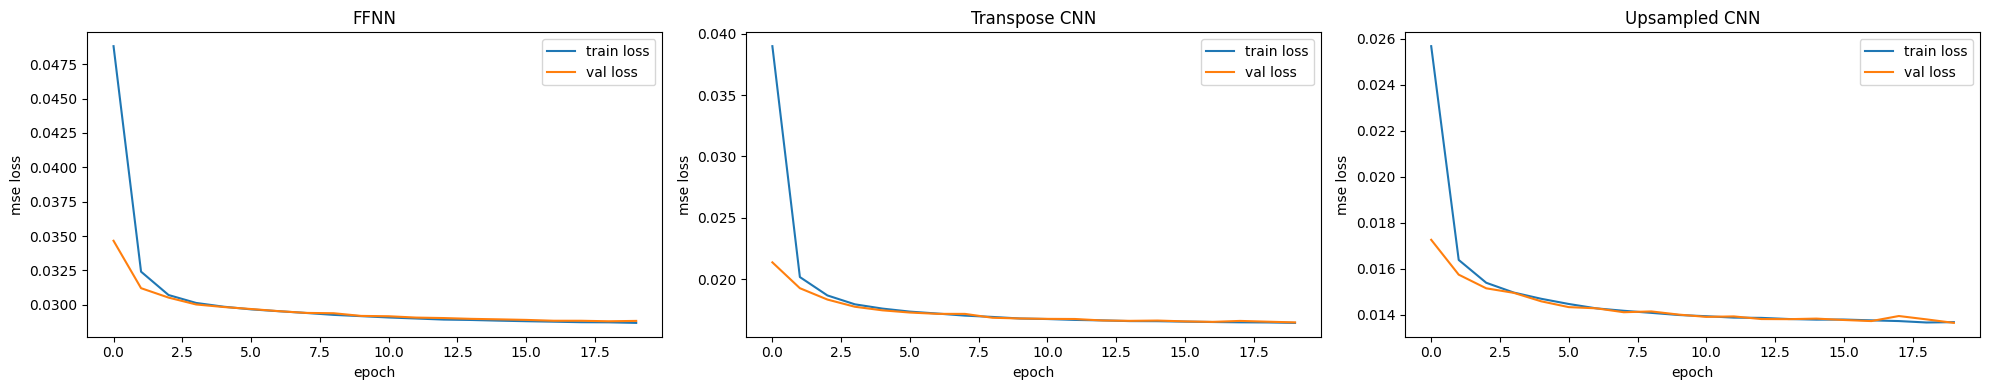

In [15]:
titles = ['FFNN', 'Transpose CNN', 'Upsampled CNN']
model_losses = [m1_loss, m2_loss, m3_loss]

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
for ax, losses, title in zip(axes, model_losses, titles):
    ax.plot(losses['train'], label='train loss')
    ax.plot(losses['valid'], label='val loss')
    ax.set_title(title)
    ax.set_xlabel('epoch')
    ax.set_ylabel('mse loss')
    ax.legend()
plt.tight_layout()
plt.show()

### testing - showing clean, noisy and reconstructed side by side

In [16]:
def test_denoising(model, state='fully', noise_factor=0.4):
    model.eval()
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)
    noisy_images = add_noise(images, noise_factor).to(device)

    with torch.no_grad():
        if state == 'fully':
            inp = noisy_images.view(noisy_images.size(0), -1)
            output = model(inp)
            output = output.view(batch_size, 1, 28, 28)
        else:
            output = model(noisy_images)

    clean_np = images.cpu().numpy()
    noisy_np = noisy_images.cpu().numpy()
    output_np = output.cpu().numpy()

    fig, axes = plt.subplots(3, 10, figsize=(20, 6))
    fig.suptitle(type(model).__name__, fontsize=11)

    for i in range(10):
        axes[0, i].imshow(np.squeeze(clean_np[i]), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(np.squeeze(noisy_np[i]), cmap='gray')
        axes[1, i].axis('off')
        axes[2, i].imshow(np.squeeze(output_np[i]), cmap='gray')
        axes[2, i].axis('off')

    axes[0,0].set_ylabel('clean', fontsize=8)
    axes[1,0].set_ylabel('noisy', fontsize=8)
    axes[2,0].set_ylabel('output', fontsize=8)
    plt.tight_layout()
    plt.show()

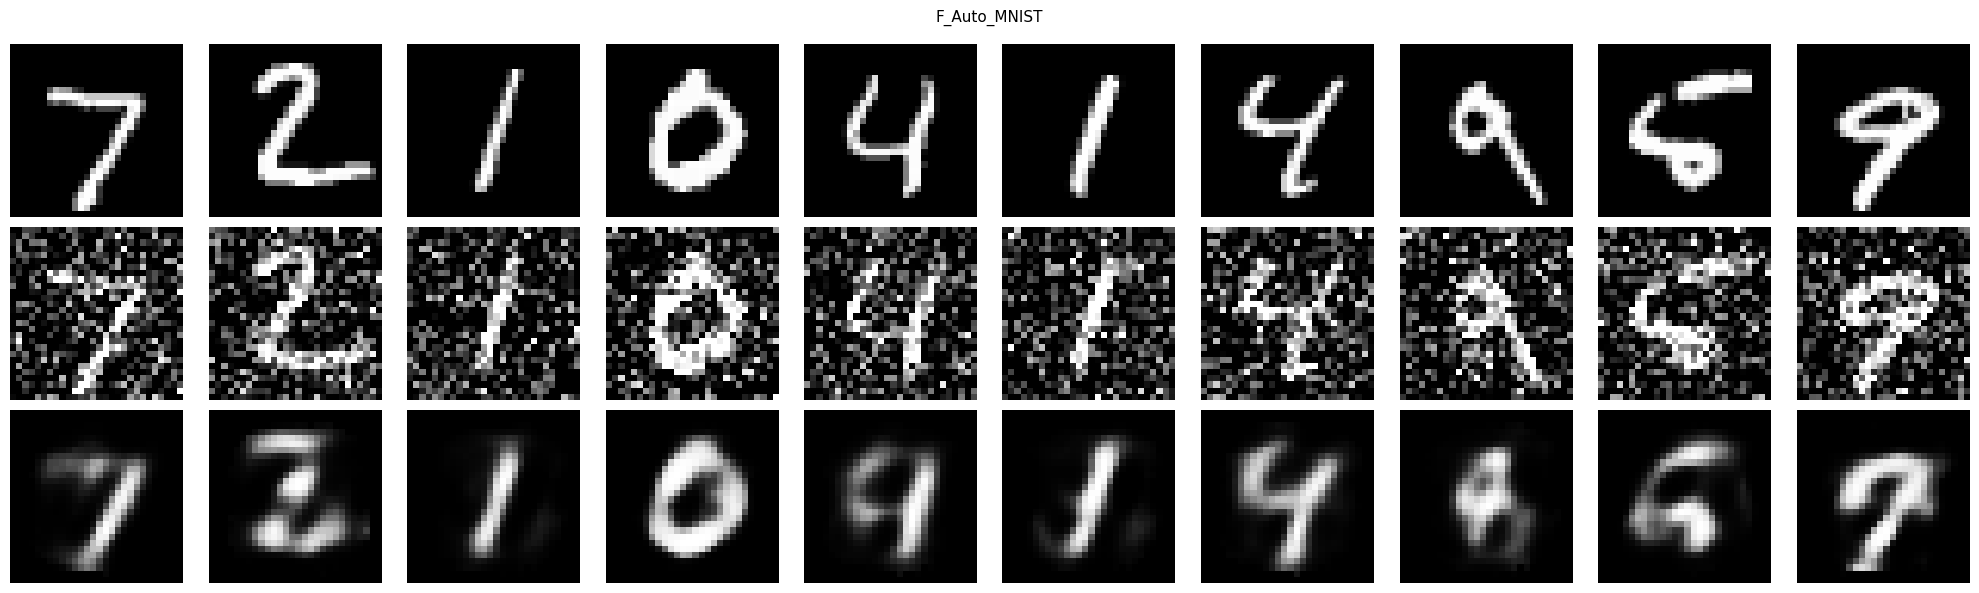

In [17]:
test_denoising(model_1, state='fully', noise_factor=0.4)

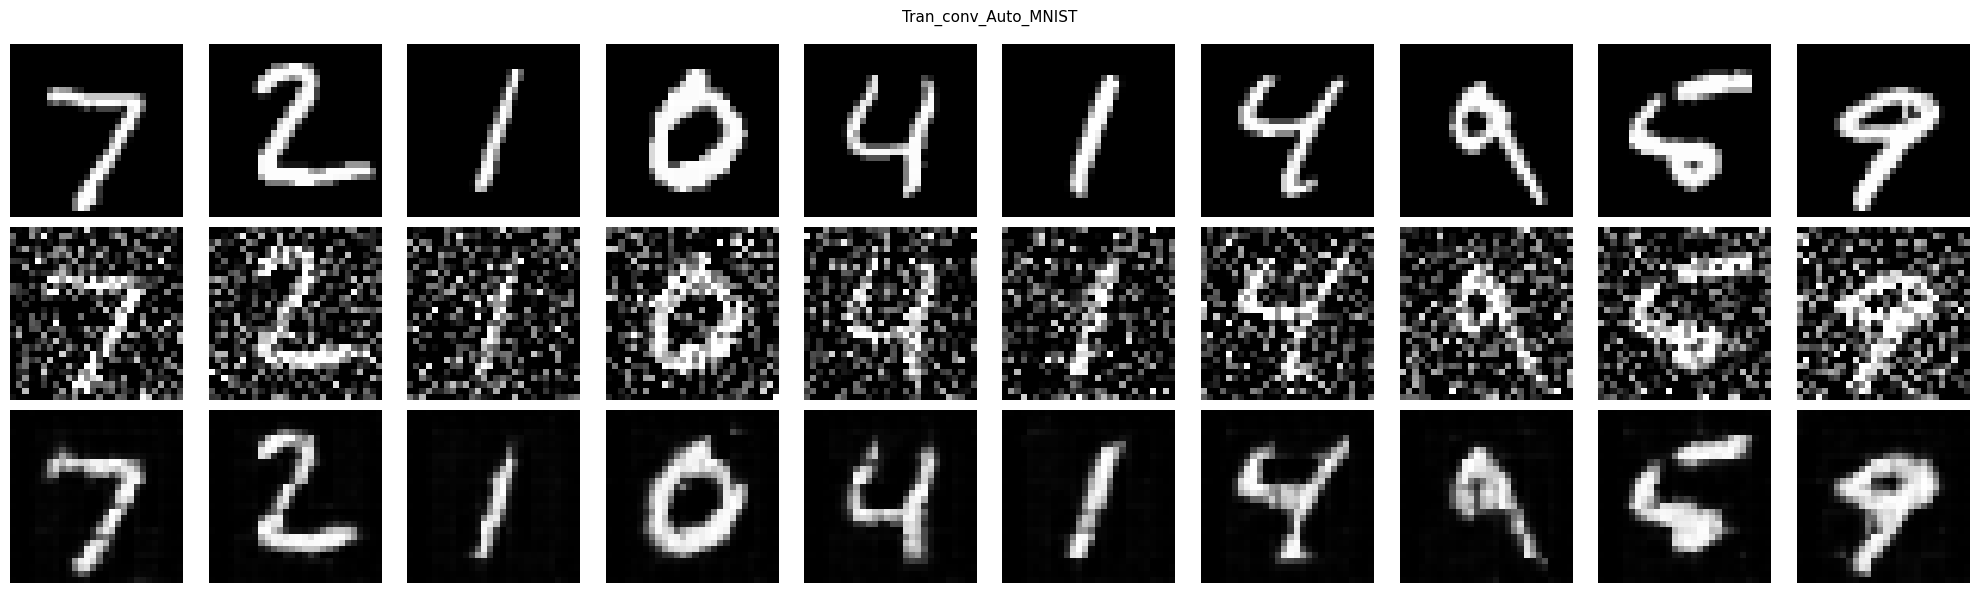

In [18]:
test_denoising(model_2, state='conv', noise_factor=0.4)

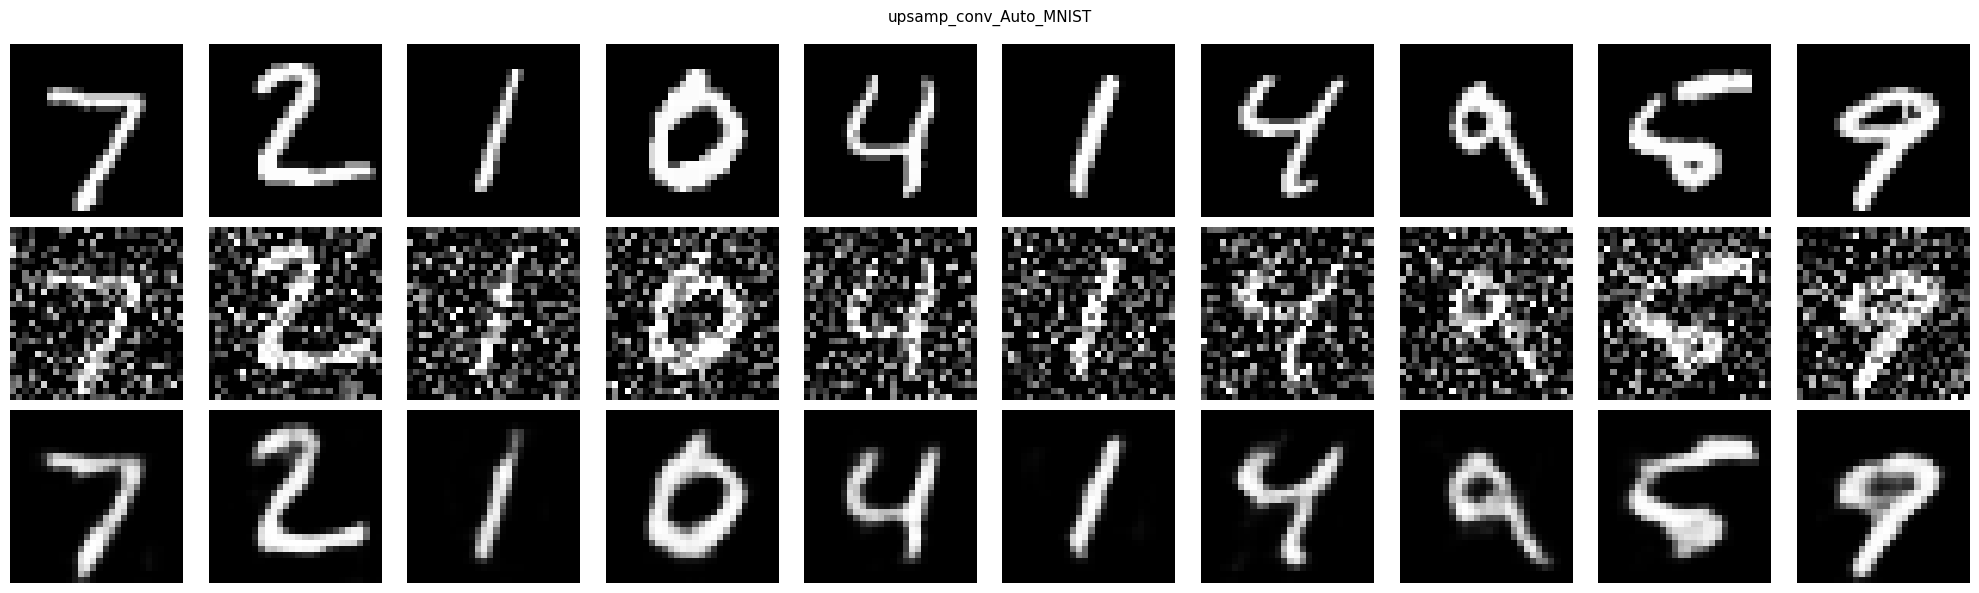

In [19]:
test_denoising(model_3, state='conv', noise_factor=0.4)

### Testing model 3 with different noise levels

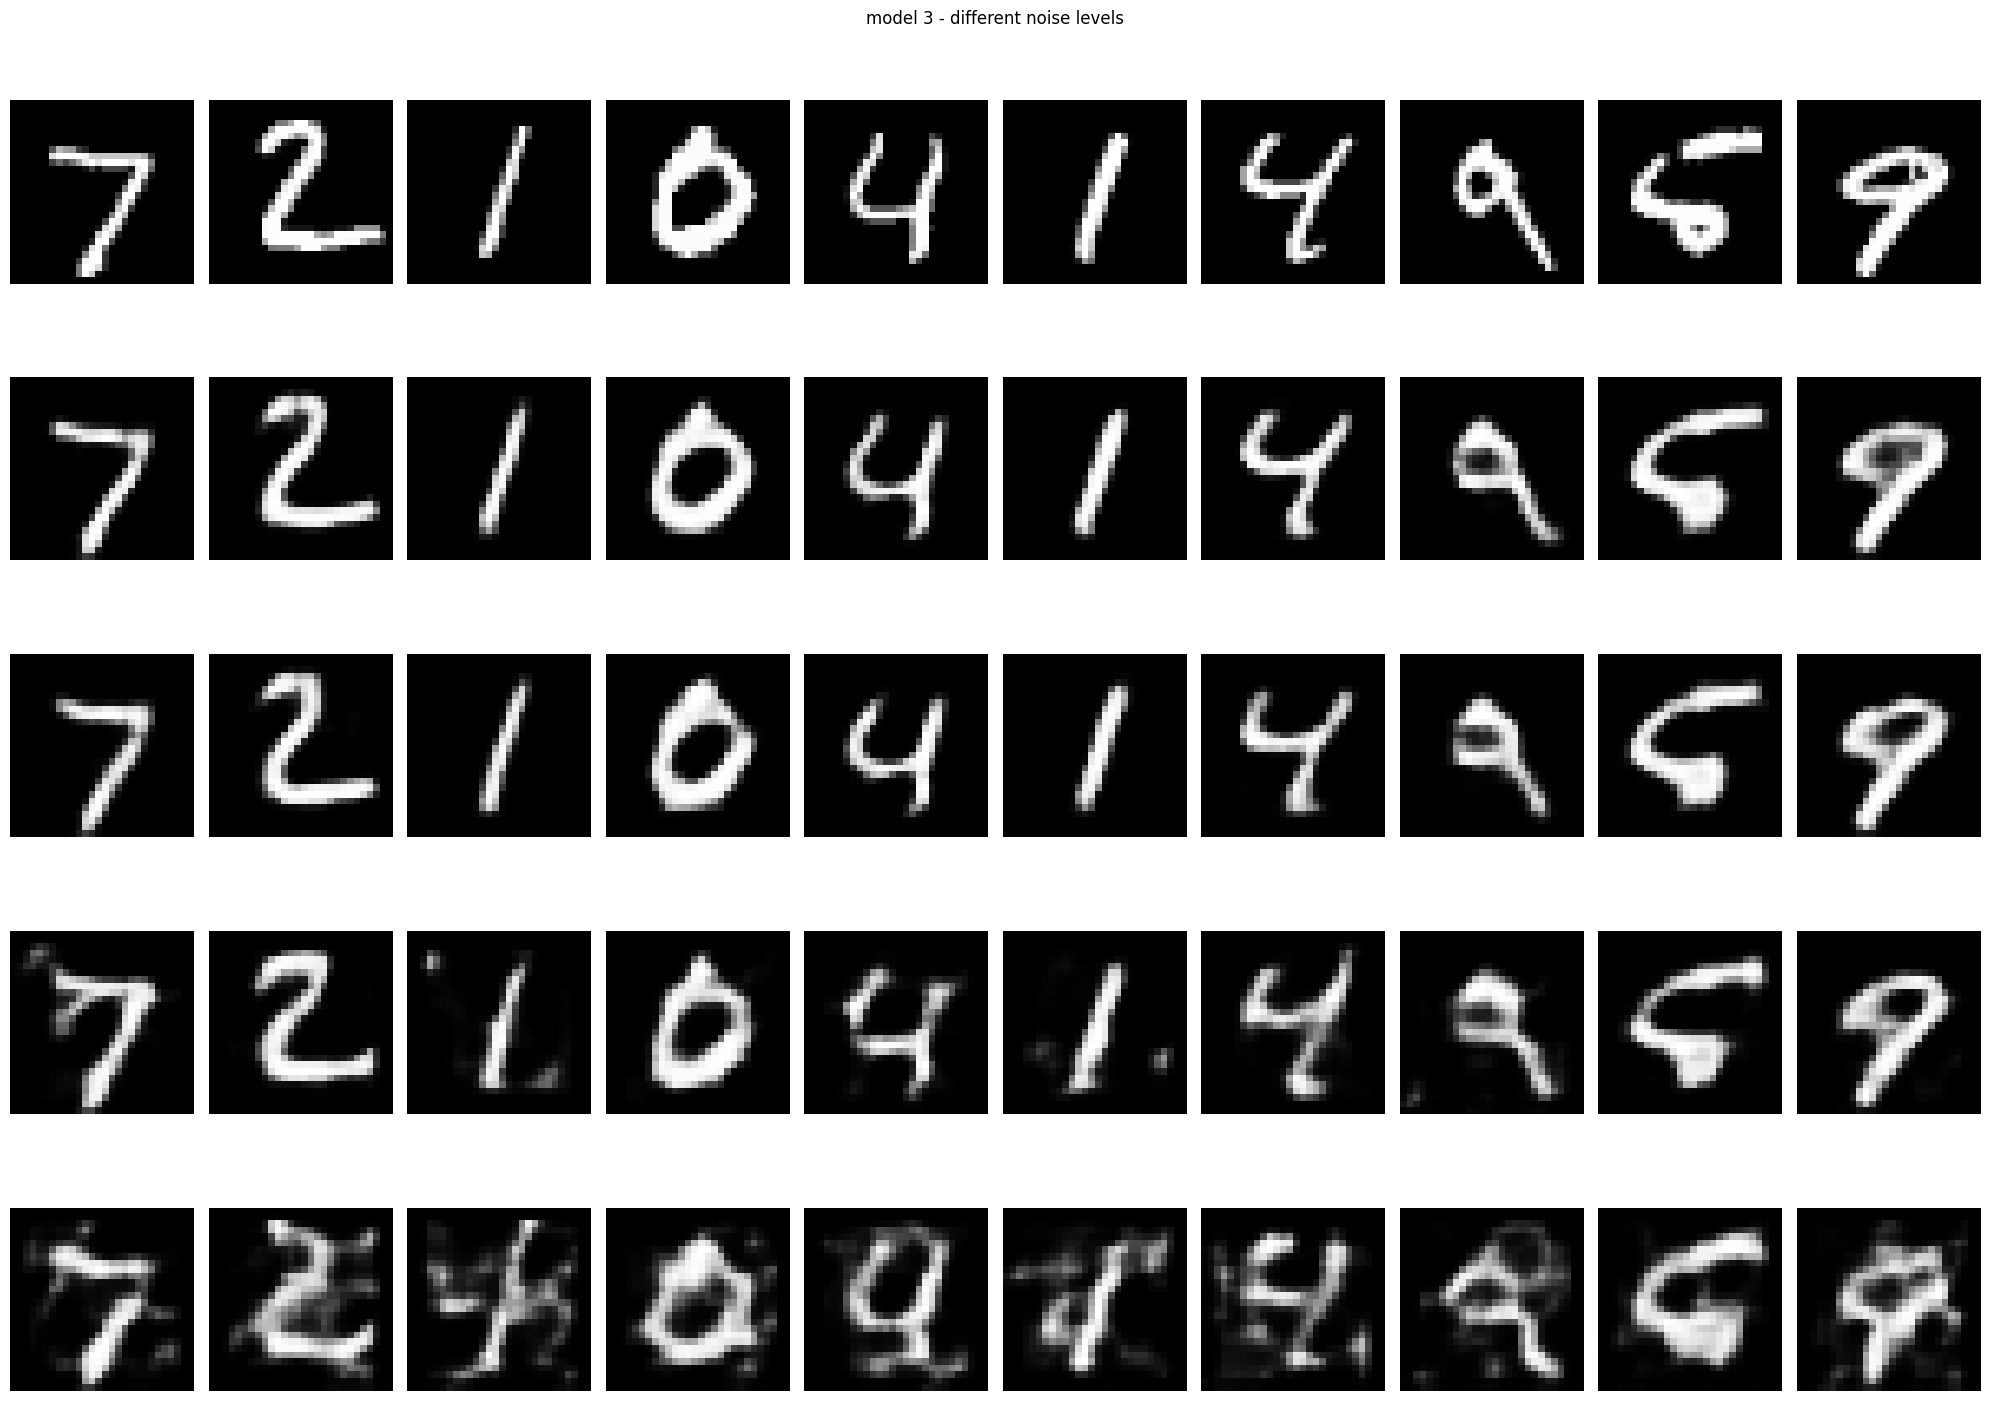

In [20]:
noise_levels = [0.1, 0.3, 0.5, 0.7]

model_3.eval()
dataiter = iter(test_loader)
images, _ = next(dataiter)
images = images.to(device)

fig, axes = plt.subplots(len(noise_levels) + 1, 10, figsize=(20, 3*(len(noise_levels)+1)))
fig.suptitle('model 3 - different noise levels', fontsize=12)

for i in range(10):
    axes[0, i].imshow(np.squeeze(images[i].cpu().numpy()), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('original', fontsize=8)

for row, nf in enumerate(noise_levels, start=1):
    noisy = add_noise(images, nf).to(device)
    with torch.no_grad():
        recon = model_3(noisy).cpu().numpy()
    for i in range(10):
        axes[row, i].imshow(np.squeeze(recon[i]), cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f'nf={nf}', fontsize=8)

plt.tight_layout()
plt.show()

CNN models work much better than the linear one for this task since images have spatial structure. model 3 gives cleaner output than model 2 because interpolation avoids checkerboard patterns that transposed convolutions sometimes cause. higher noise makes output slightly blurry but structure is still recovered.